In [ ]:
!pip install catboost

import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [ ]:
df = pd.read_csv("df_final2.csv")

In [ ]:
df.head()

,ASN,TTL,subdomain,len,entropy,Domain_Age,numeric_percentage,Name_Server_Count,obfuscate_at_sign,vowel_count,...,tld,Registrar,sld,IP_Subnet,Domain,Domain_Name,Registrant_Name,longest_word,Emails,label
0,15169.0,46,0.0,7.0,1.834876,8256.0,0.0,8.0,0,3,...,com,MarkMonitor Inc.,google,172.217,google.com,"['GOOGLE.COM', 'google.com']",NaN,google,"['abusecomplaints@markmonitor.com', 'whoisrequ...",0
1,NaN,299,0.0,7.0,1.834876,8256.0,0.0,8.0,0,3,...,com,MarkMonitor Inc.,google,NaN,google.com,"['GOOGLE.COM', 'google.com']",NaN,google,"['abusecomplaints@markmonitor.com', 'whoisrequ...",0
2,NaN,38,1.0,10.0,2.114247,8256.0,0.0,4.0,0,3,...,com,MarkMonitor Inc.,google,NaN,www.google.com,GOOGLE.COM,NaN,google,abusecomplaints@markmonitor.com,0
3,15169.0,299,1.0,10.0,2.114247,-1.0,0.0,NaN,0,3,...,com,unknown,google,172.217,www.google.com,NaN,NaN,google,NaN,0
4,NaN,96,0.0,9.0,2.595489,8426.0,0.0,4.0,0,4,...,com,RegistrarSafe LLC,facebook,NaN,facebook.com,FACEBOOK.COM,NaN,facebook,"['abusecomplaints@registrarsafe.com', 'domain@...",0


In [ ]:
label_map = {
    0: "Benign",
    1: "Malware",
    2: "Phishing",
    3: "Spam"
}

df['label_name'] = df['label'].map(label_map)

df[['label', 'label_name']].head()
class_counts = df['label_name'].value_counts()
class_percent = df['label_name'].value_counts(normalize=True) * 100

print("Counts:")
print(class_counts)

print("\nPercentages:")
print(class_percent)

Counts:
label_name
Benign      471893
Malware       4605
Phishing      4535
Spam          4317
Name: count, dtype: int64

Percentages:
label_name
Benign      97.227362
Malware      0.948800
Phishing     0.934377
Spam         0.889461
Name: proportion, dtype: float64


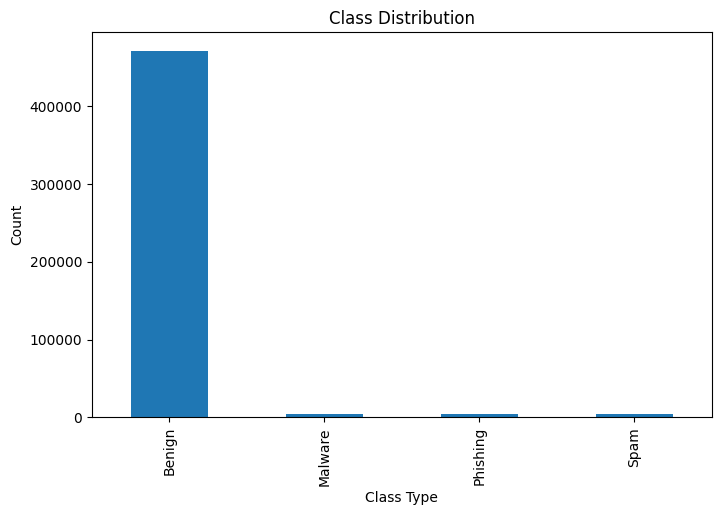

In [ ]:
plt.figure(figsize=(8,5))
df['label_name'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class Type")
plt.ylabel("Count")

plt.show()

In [ ]:
# Target
y = df['label']

# Features
X = df.drop(['label', 'label_name'], axis=1)

X.head()

,ASN,TTL,subdomain,len,entropy,Domain_Age,numeric_percentage,Name_Server_Count,obfuscate_at_sign,vowel_count,...,Organization,tld,Registrar,sld,IP_Subnet,Domain,Domain_Name,Registrant_Name,longest_word,Emails
0,15169.0,46,0.0,7.0,1.834876,8256.0,0.0,8.0,0,3,...,Google LLC,com,MarkMonitor Inc.,google,172.217,google.com,"['GOOGLE.COM', 'google.com']",NaN,google,"['abusecomplaints@markmonitor.com', 'whoisrequ..."
1,NaN,299,0.0,7.0,1.834876,8256.0,0.0,8.0,0,3,...,Google LLC,com,MarkMonitor Inc.,google,NaN,google.com,"['GOOGLE.COM', 'google.com']",NaN,google,"['abusecomplaints@markmonitor.com', 'whoisrequ..."
2,NaN,38,1.0,10.0,2.114247,8256.0,0.0,4.0,0,3,...,unknown,com,MarkMonitor Inc.,google,NaN,www.google.com,GOOGLE.COM,NaN,google,abusecomplaints@markmonitor.com
3,15169.0,299,1.0,10.0,2.114247,-1.0,0.0,NaN,0,3,...,unknown,com,unknown,google,172.217,www.google.com,NaN,NaN,google,NaN
4,NaN,96,0.0,9.0,2.595489,8426.0,0.0,4.0,0,4,...,Facebook Inc.,com,RegistrarSafe LLC,facebook,NaN,facebook.com,FACEBOOK.COM,NaN,facebook,"['abusecomplaints@registrarsafe.com', 'domain@..."


In [ ]:
# Numerical Features
numerical_features = [
    'ASN', 'TTL', 'subdomain', 'len', 'entropy', 'Domain_Age',
    'numeric_percentage', 'Name_Server_Count', 'obfuscate_at_sign',
    'vowel_count', 'vowel_ratio'
]

# Categorical Features
categorical_features = [
    'Country', 'State', 'Organization', 'tld',
    'Registrar', 'sld', 'IP_Subnet'
]

# Text Features
text_features = [
    'Domain', 'Domain_Name', 'Registrant_Name',
    'longest_word', 'Emails'
]

# Target
target = 'label'

X = df[numerical_features + categorical_features + text_features]
y = df[target]

# CatBoost categorical features
cat_features = categorical_features + text_features

In [ ]:
# Fill categorical + text features
for col in categorical_features + text_features:
    X[col] = X[col].fillna("missing").astype(str)

# Fill numerical features
for col in numerical_features:
    X[col] = X[col].fillna(0)
# Remove rows where target is NaN
mask = y.notna()
X = X[mask]
y = y[mask]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

/tmp/ipykernel_9288/1244355973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna("missing").astype(str)
/tmp/ipykernel_9288/1244355973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna("missing").astype(str)
/tmp/ipykernel_9288/1244355973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

Train shape: (388280, 23)
Test shape: (97070, 23)


In [ ]:
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# classes = np.unique(y_train)

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=classes,
#     y=y_train
# )

# class_weights

In [ ]:
from catboost import CatBoostClassifier

# Treat these as categorical instead of text
extra_cat_features = ['Domain', 'Domain_Name', 'Emails']

# Ensure they are strings
for col in extra_cat_features:
    X_train[col] = X_train[col].fillna('').astype(str)
    X_test[col] = X_test[col].fillna('').astype(str)

# Add to existing categorical features
cat_features = cat_features + extra_cat_features


model = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    auto_class_weights='SqrtBalanced',
    random_state=42,
    verbose=100,
    text_processing=['NaiveBayes+Letter|BoW+Letter,BiGram,TriGram']
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

0:	learn: 0.7740456	test: 0.7810242	best: 0.7810242 (0)	total: 1.32s	remaining: 17m 32s
100:	learn: 0.9141953	test: 0.9446108	best: 0.9446148 (97)	total: 2m 3s	remaining: 14m 17s
200:	learn: 0.9204065	test: 0.9488641	best: 0.9488641 (200)	total: 4m 30s	remaining: 13m 25s
300:	learn: 0.9242465	test: 0.9512102	best: 0.9513208 (292)	total: 7m 2s	remaining: 11m 40s
400:	learn: 0.9275585	test: 0.9520191	best: 0.9520760 (358)	total: 9m 34s	remaining: 9m 32s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9527999116
bestIteration = 448

Shrink model to first 449 iterations.


CatBoostClassifier(auto_class_weights='SqrtBalanced', depth=6, eval_metric='TotalF1', iterations=800, learning_rate=0.05, loss_function='MultiClass', random_state=42, text_processing=['NaiveBayes+Letter|BoW+Letter,BiGram,TriGram'], verbose=100)

In [ ]:
preds = model.predict(X_test).flatten()
probs = model.predict_proba(X_test)

preds[:5], probs[:5]



(array([0, 0, 0, 0, 0]),
 array([[9.36712823e-01, 3.67008303e-02, 2.53599020e-02, 1.22644430e-03],
        [9.93467379e-01, 3.68518684e-03, 2.77249684e-03, 7.49376993e-05],
        [9.93467097e-01, 1.57617557e-03, 3.98745915e-03, 9.69268166e-04],
        [8.24491998e-01, 1.05248037e-01, 6.93143139e-02, 9.45650697e-04],
        [9.97077427e-01, 2.23017770e-03, 6.88885683e-04, 3.50968175e-06]]))

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds, target_names=label_map.values()))

              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     94379
     Malware       0.60      0.62      0.61       921
    Phishing       0.88      0.86      0.87       907
        Spam       0.93      1.00      0.96       863

    accuracy                           0.99     97070
   macro avg       0.85      0.87      0.86     97070
weighted avg       0.99      0.99      0.99     97070



In [ ]:
print(confusion_matrix(y_test, preds))

[[93861   361   100    57]
 [  341   570     6     4]
 [  113    12   780     2]
 [    0     0     0   863]]


In [ ]:
weights = np.array([0.0, 1.0, 0.3, 0.3])

raw_scores = np.dot(probs, weights)

risk_scores = raw_scores * 100

risk_scores[:10]

array([ 4.46767342,  0.45394172,  0.30631938, 12.63260268,  0.24378963,
        0.12430405,  0.58772027,  0.77429432,  0.18012318,  0.28486508])

In [ ]:
def risk_category(score):
    if score <= 20:
        return "Low"
    elif score <= 70:
        return "Medium"
    elif score <= 90:
        return "High"
    else:
        return "Critical"

risk_levels = [risk_category(score) for score in risk_scores]

risk_levels[:10]

['Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low']

In [ ]:
feature_importance = model.get_feature_importance(prettified=True)

feature_importance.head(20)

,Feature Id,Importances
0,sld,18.365805
1,Domain_Age,14.565570
2,TTL,9.794885
3,IP_Subnet,7.996088
4,longest_word,7.855451
5,ASN,4.236892
6,subdomain,4.146702
7,entropy,4.051943
8,tld,4.032937
9,Registrar,4.026644


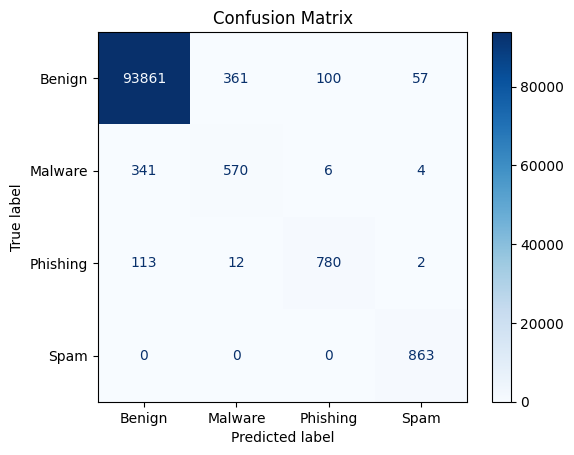

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malware", "Phishing", "Spam"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

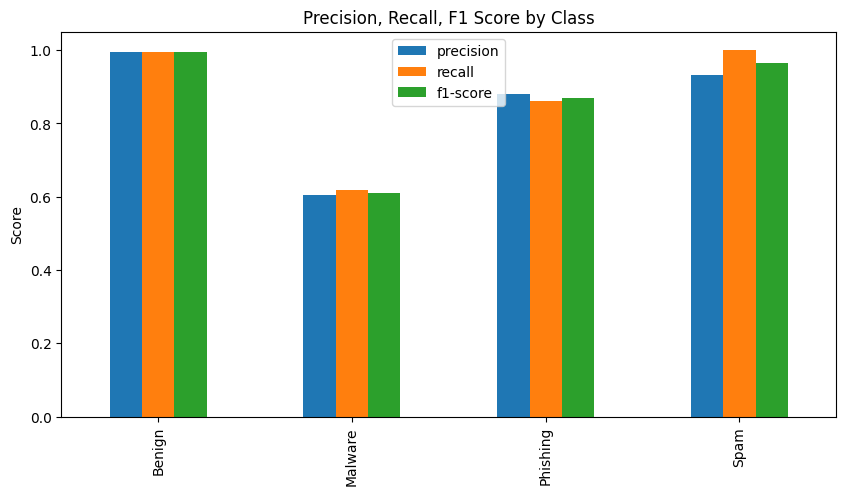

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    preds,
    target_names=["Benign", "Malware", "Phishing", "Spam"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df[['precision', 'recall', 'f1-score']].iloc[:-3].plot(kind='bar', figsize=(10,5))
plt.title("Precision, Recall, F1 Score by Class")
plt.ylabel("Score")
plt.show()

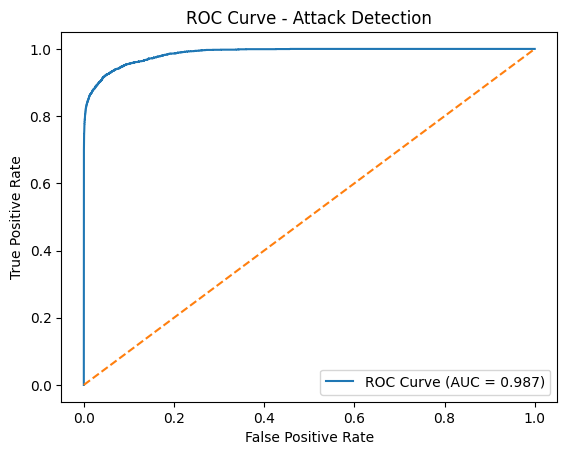

In [ ]:
from sklearn.metrics import roc_curve, auc

y_binary = (y_test != 0).astype(int)

attack_probs = probs[:,1:].sum(axis=1)

fpr, tpr, _ = roc_curve(y_binary, attack_probs)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Attack Detection")
plt.legend()
plt.show()

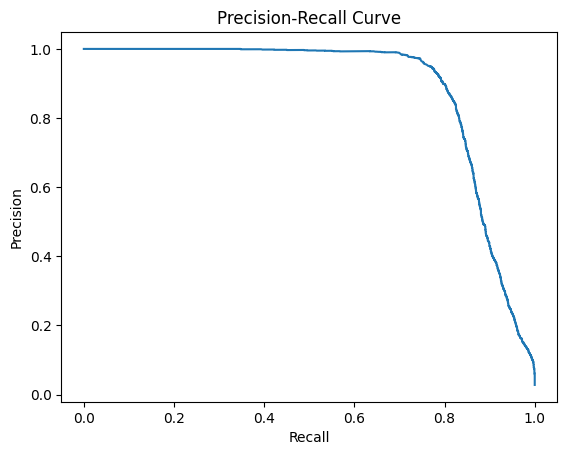

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_binary, attack_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

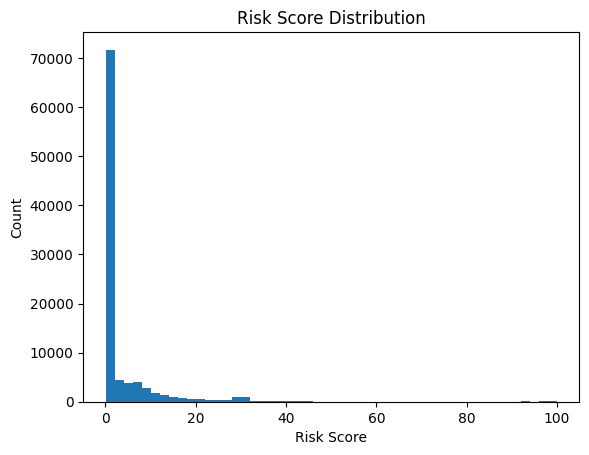

In [ ]:
risk_scores = np.dot(probs, weights) * 100

plt.hist(risk_scores, bins=50)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

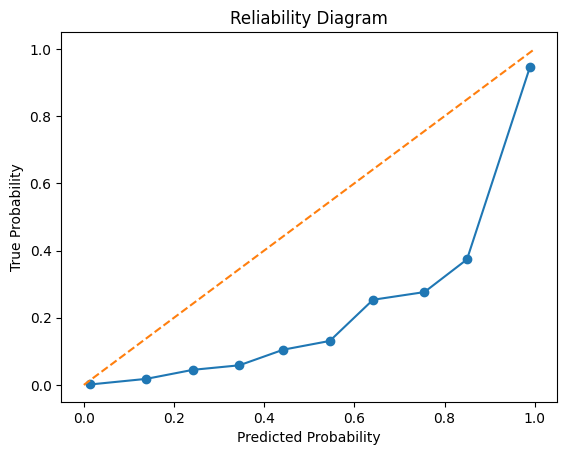

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_binary, attack_probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Reliability Diagram")
plt.show()